## Taller Deep Learning

Introducción

Importar librerias

In [2]:
import os 
import numpy as np  
from PIL import Image  
import tensorflow as tf  
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D  # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping  # Importa el callback
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

2025-10-02 21:19:25.040957: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 21:19:25.093271: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-02 21:19:26.730420: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Redimensionar y normalizar imágenes

In [3]:
# Directorio original y reducido
d_original = '/home/fisica/bandas/banda13/ene_01_mes'
d_reducida = '/home/fisica/bandas/banda13/ene_01_reducida_mes'


# Función de redimensionado - TAMAÑO PEQUEÑO PARA PRUEBAS
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)
# Se llama a la función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


## Implementación de una Red Neuronal Convolucional

In [6]:
# Definición del modelo
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError

model = Sequential([
    # Encoder
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Bottleneck
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    # Decoder
    UpSampling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    # Output
    Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

model.compile(
    optimizer="adam", 
    loss="mse", 
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model.summary()

# Entrenamiento 15 épocas, batch size 8, early stopping
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X, y,
    epochs=10,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")

Resumen del modelo:


/home/fisica/data/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-02 21:18:54.270386: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 480, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 240, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 240, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 120, 120, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 240, 240, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 240, 240, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 240, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 480, 480, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 480, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,497 (728.50 KB)

 Trainable params: 185,857 (726.00 KB)

 Non-trainable params: 640 (2.50 KB)

Iniciando entrenamiento de prueba...


2025-10-02 21:18:55.197122: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 681984000 exceeds 10% of free system memory.


KeyboardInterrupt: 

In [4]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.0172 - mean_absolute_percentage_error: 1235.6847 - root_mean_squared_error: 0.1313
Pérdida (MSE): 0.0172
RMSE: 0.1313
MAPE: 1235.6847


24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step


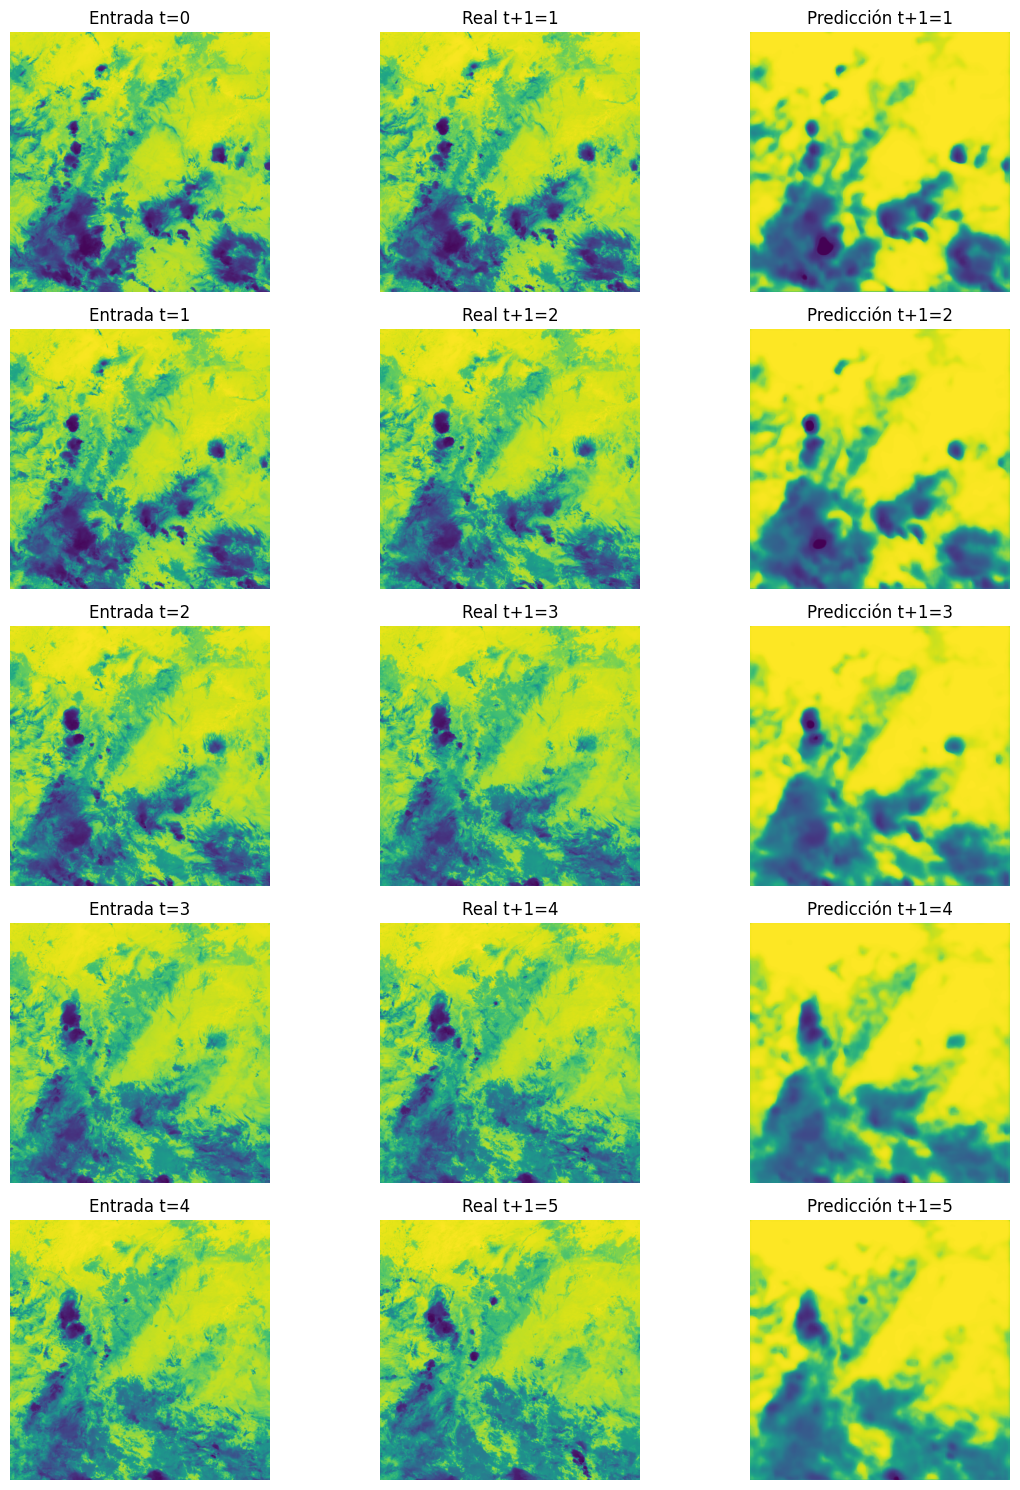

In [5]:
import matplotlib.pyplot as plt

# Selecciona el número de ejemplos a mostrar
n = 5

y_pred = model.predict(X)  # Genera las predicciones

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
print("Valores reales:", np.min(y), np.max(y))
print("Valores predichos:", np.min(y_pred), np.max(y_pred))

Valores reales: 0.0 1.0
Valores predichos: 0.16423309 0.61714697


# Entrenamiento

In [4]:
# Definición del modelo
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError

model1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    
    Conv2D(1, (3, 3), activation='linear', padding='same')  # SIN BatchNorm en la salida
])

model1.compile(
    optimizer="adam", 
    loss="mse", 
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model1.summary()

# Entrenamiento 15 épocas, batch size 8, early stopping
print("Iniciando entrenamiento")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history1 = model1.fit(
    X, y,
    epochs=15,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")

Resumen del modelo:


/home/fisica/data/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-02 21:26:11.055422: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,529 (181.75 KB)

...

2025-10-02 21:26:11.902425: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 681984000 exceeds 10% of free system memory.


Epoch 1/15


2025-10-02 21:26:13.740364: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 681984000 exceeds 10% of free system memory.
2025-10-02 21:26:15.763807: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 117964800 exceeds 10% of free system memory.
2025-10-02 21:26:15.930982: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 235929600 exceeds 10% of free system memory.
2025-10-02 21:26:16.047373: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 471859200 exceeds 10% of free system memory.


93/93 ━━━━━━━━━━━━━━━━━━━━ 1122s 12s/step - loss: 0.0408 - mean_absolute_percentage_error: 1553.1835 - root_mean_squared_error: 0.2020
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1047s 11s/step - loss: 0.0081 - mean_absolute_percentage_error: 1405.4161 - root_mean_squared_error: 0.0900
Epoch 3/15
18/93 ━━━━━━━━━━━━━━━━━━━━ 14:46 12s/step - loss: 0.0080 - mean_absolute_percentage_error: 1350.4559 - root_mean_squared_error: 0.0893

KeyboardInterrupt: 

In [ ]:
# ================== GUARDAR MODELO ==================

# 1. Guardar el modelo completo como .h5 (recomendado para modelos Keras)
model1.save('/home/fisica/monografia_esp_cd/modelo1_conv2d_banda13.h5')
print("Modelo guardado como .h5")

# 2. Guardar el historial y metadatos como .pkl
# Evaluar métricas finales
final_loss, final_rmse, final_mape = model1.evaluate(X, y, verbose=0)

# Crear diccionario con toda la información del modelo
model1_info = {
    'nombre_modelo': 'model1_conv2d_banda13',
    'arquitectura': 'Conv2D_Simple_SinBatchNorm',
    'descripcion': 'Modelo encoder-decoder simétrico con 6 capas Conv2D',
    'canales_entrada': 1,  # Solo banda 13
    'forma_entrada': X.shape[1:],
    'forma_salida': y.shape[1:],
    'numero_parametros': model1.count_params(),
    'epocas_entrenadas': len(history1.history['loss']),
    'batch_size': 8,
    'optimizer': 'adam',
    'loss_function': 'mse',
    'callbacks_usados': ['EarlyStopping'],
    'metricas_finales': {
        'loss_mse': final_loss,
        'rmse': final_rmse,
        'mape': final_mape
    },
    'historial_entrenamiento': {
        'loss': history1.history['loss'],
        'root_mean_squared_error': history1.history['root_mean_squared_error'],
        'mean_absolute_percentage_error': history1.history['mean_absolute_percentage_error']
    },
    'datos_entrenamiento': {
        'num_ejemplos': X.shape[0],
        'resolucion_imagenes': '480x480',
        'banda_espectral': 'banda13',
        'periodo_datos': 'enero_2024',
        'normalizacion': 'min_max_individual'
    }
}

# Guardar como .pkl
with open('/home/fisica/monografia_esp_cd/modelo1_info_completa.pkl', 'wb') as f:
    pickle.dump(model1_info, f)

print("Información completa guardada como .pkl")

# 3. Solo el historial de entrenamiento (más ligero)
with open('/home/fisica/monografia_esp_cd/modelo1_historial.pkl', 'wb') as f:
    pickle.dump(history1.history, f)

print("Historial de entrenamiento guardado como .pkl")

print("=== ARCHIVOS GENERADOS ===")
print("1. modelo1_conv2d_banda13.h5 - Modelo completo para predicciones")
print("2. modelo1_info_completa.pkl - Información completa + historial")
print("3. modelo1_historial.pkl - Solo historial de entrenamiento")
print(f"Ubicación: /home/fisica/monografia_esp_cd/")

In [7]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model1.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 727ms/step - loss: 0.5647 - mean_absolute_percentage_error: 121.5629 - root_mean_squared_error: 0.7515
Pérdida (MSE): 0.5647
RMSE: 0.7515
MAPE: 121.5629


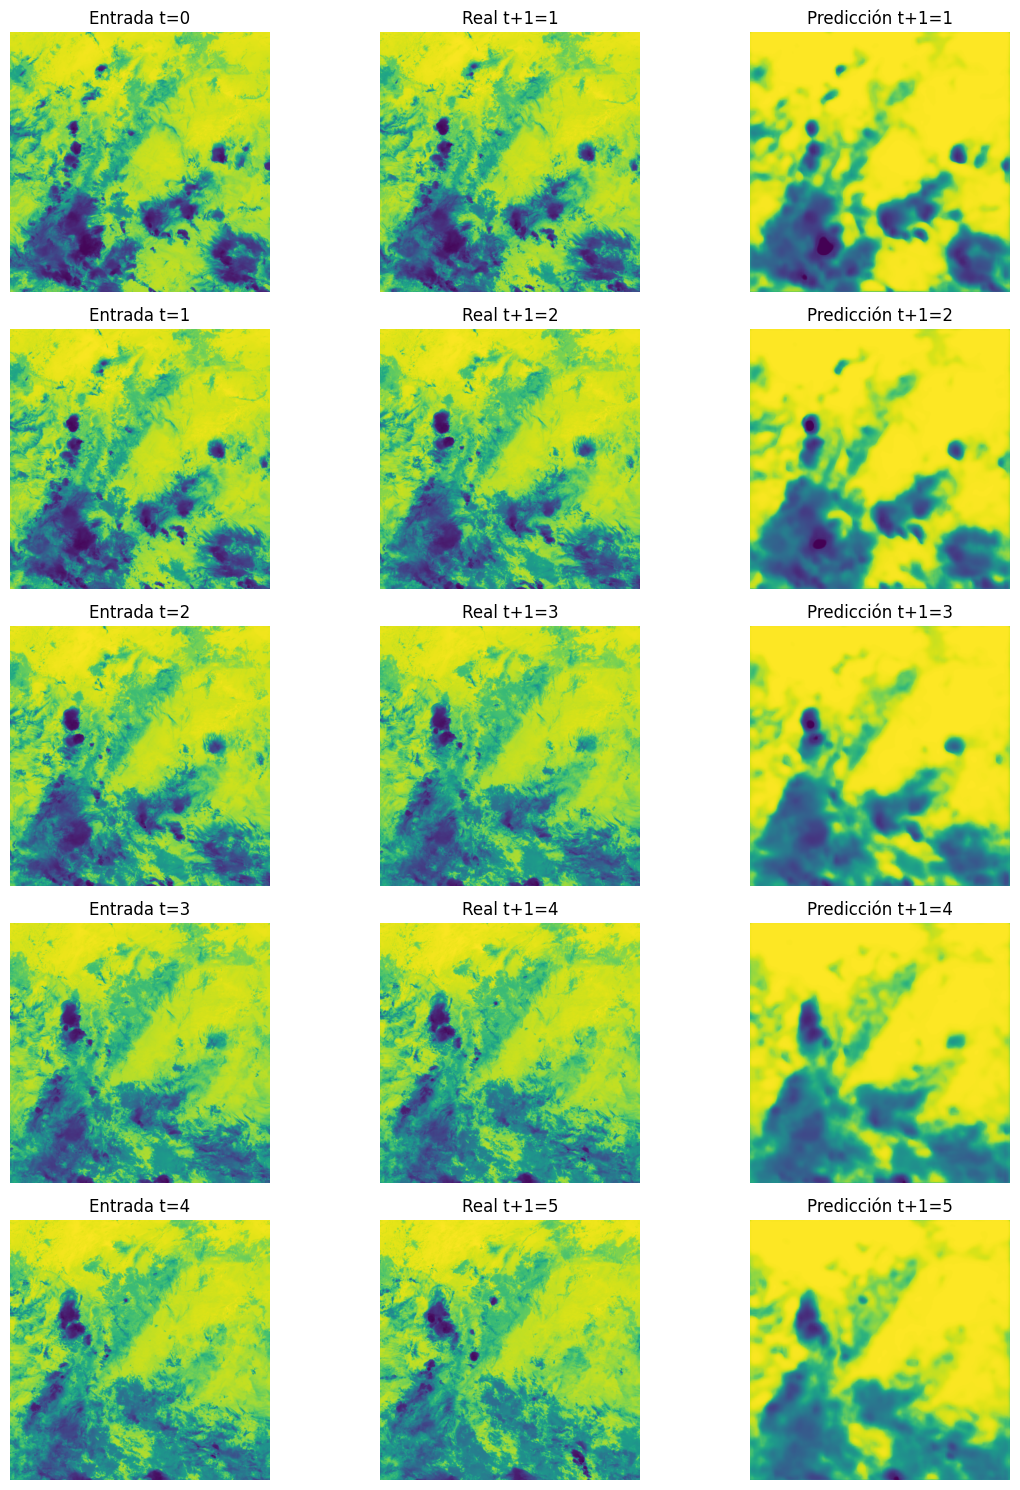

In [ ]:
import matplotlib.pyplot as plt

y_pred1 = model1.predict(X)  # Genera las predicciones

# Selecciona el número de ejemplos a mostrar
n = 5

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred1[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Validación con una semana de febrero

In [ ]:
# Directorio original y reducido
d_feb_1s = '/home/fisica/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = '/home/fisica/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

In [ ]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model1.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

In [ ]:
import matplotlib.pyplot as plt

y_pred_val = model1.predict(X_val)  # Genera las predicciones

# Selecciona el número de ejemplos a mostrar
n = 5

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X_val[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y_val[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred_val[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Usando 2 canales el 9 y el 13

In [6]:
# Directorio de las nuevas imágenes 920x920 y su destino reducido
d_original_9 = '/home/fisica/bandas/banda9/ene_01'  # Cambia esta ruta por la ubicación real
d_reducida_9 = '/home/fisica/bandas/banda9/ene_01_reducida'  # Cambia esta ruta por el destino deseado

# Redimensionar las imágenes 920x920 a 480x480 usando la función existente
resize_npy_images(d_original_9, d_reducida_9, new_size=(480, 480))

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida_9) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_9 = [np.load(os.path.join(d_reducida_9, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_9 = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_9]
images_9 = [np.clip(img, 0, 1) for img in images_9]  # Limita los valores al rango [0, 1]
X_1 = np.array(images_9[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_1 = np.array(images_9[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal


Procesando 23 imágenes


In [ ]:
X_multi = np.concatenate([X, X_1], axis=-1)  # (n, 480, 480, 2)
y_multi = np.concatenate([y, y_1], axis=-1)  # (n, 480, 480, 2)

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X_multi.shape[1:]),
    BatchNormalization(),  # 1. Después de la primera capa
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),  # 2. Después de la segunda capa
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),  # 3. Después de la tercera capa (pico del encoder)
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),  # 4. Después de la cuarta capa
    
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),  # 5. Después de la quinta capa
    
    Conv2D(1, (3, 3), activation='linear', padding='same')  # SIN BatchNorm en la salida
])

model.compile(
    optimizer="adam", 
    loss="mse", 
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model.summary()

# Entrenamiento rápido - solo 3 épocas
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_multi, y_multi,
    epochs=10,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")



Resumen del modelo:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 480, 480, 16)   │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,673 (182.32 KB)

 Trainable params: 46,673 (182.32 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando entrenamiento de prueba...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 8s/step - loss: 0.5740 - mae: 0.5740
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - loss: 0.2423 - mae: 0.2423
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - loss: 0.1871 - mae: 0.1871
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - loss: 0.1903 - mae: 0.1903
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - loss: 0.1215 - mae: 0.1215
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step - loss: 0.1348 - mae: 0.1348
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - loss: 0.1039 - mae: 0.1039
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - loss: 0.1135 - mae: 0.1135
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - loss: 0.0999 - mae: 0.0999
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - loss: 0.0967 - mae: 0.0967
¡Prueba completada!
Pérdida final: 0.0967


2025-09-24 19:56:04.348934: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 648806400 exceeds 10% of free system memory.
2025-09-24 19:56:04.627000: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1297612800 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


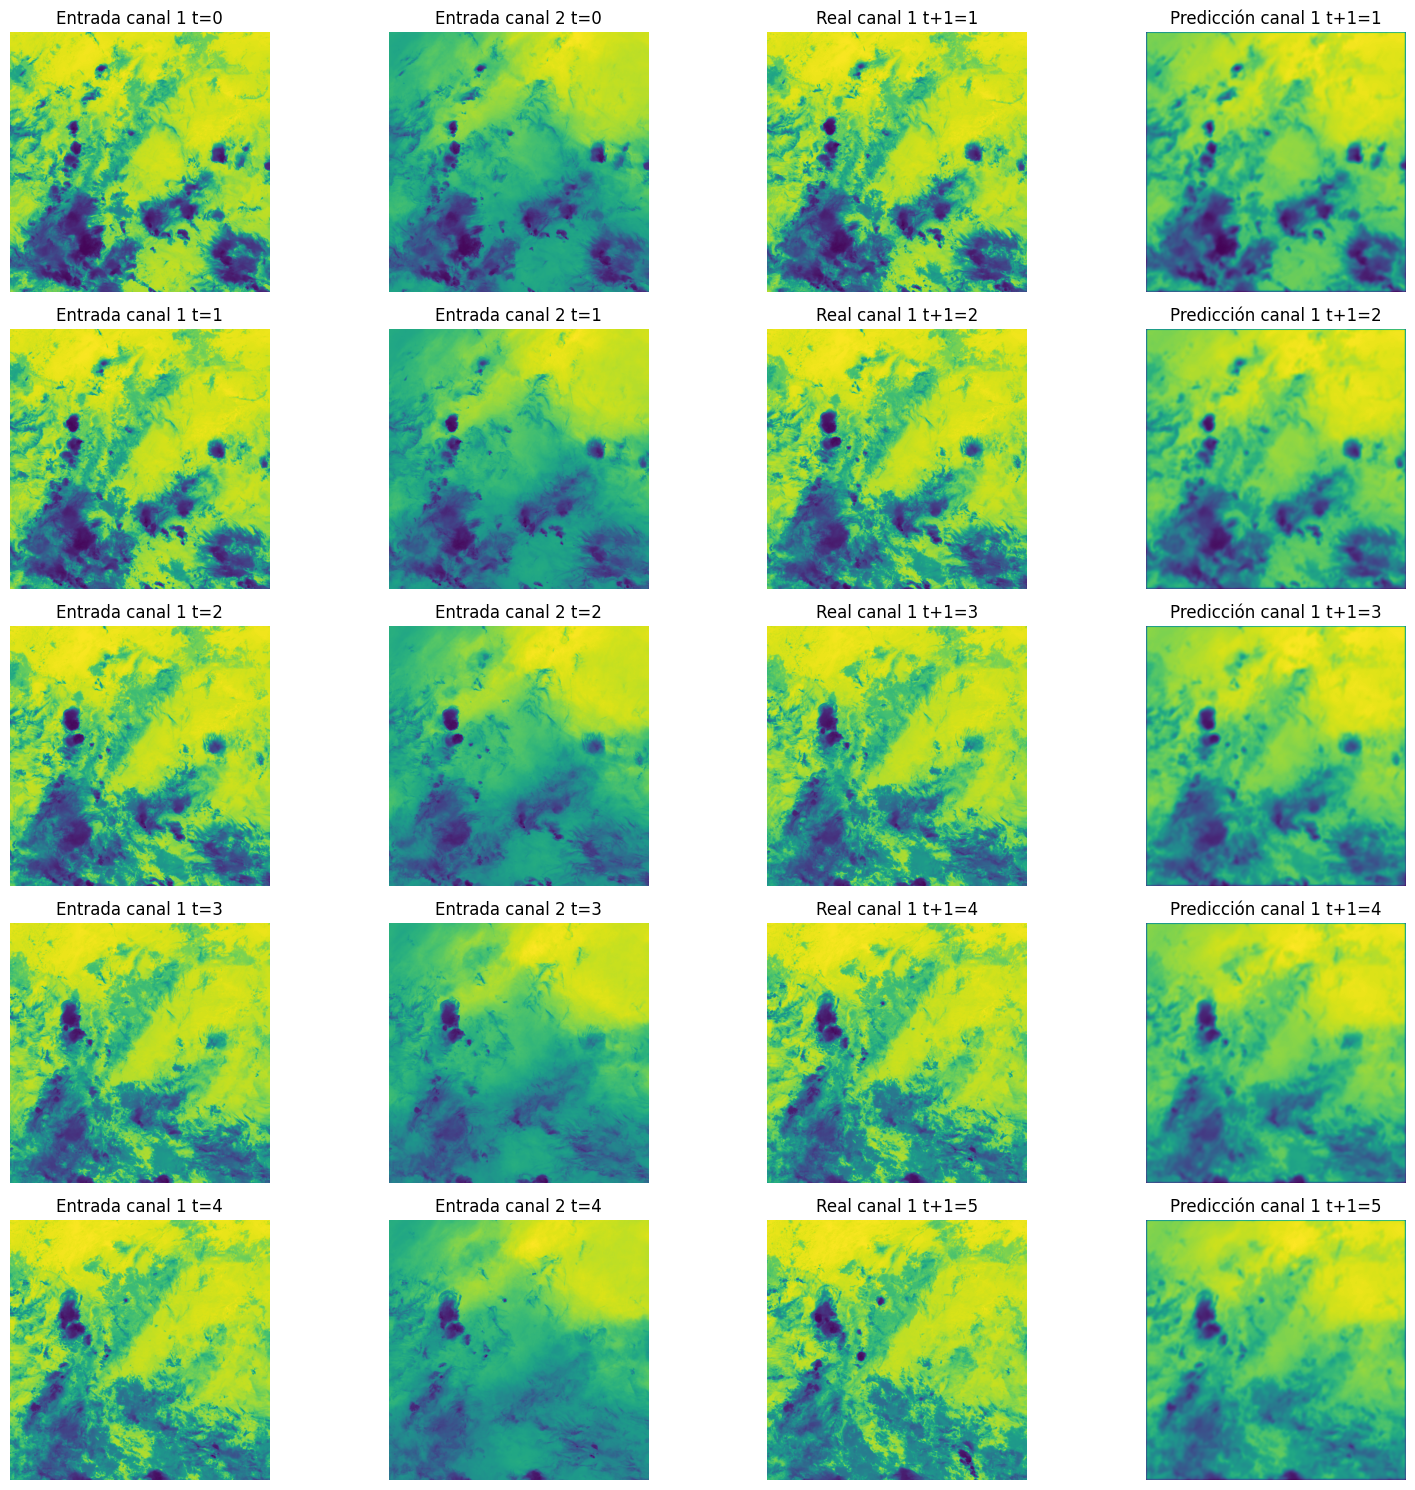

In [8]:
import matplotlib.pyplot as plt

# Generar predicciones con el modelo entrenado
y_pred = model.predict(X_multi)

# Número de ejemplos a mostrar
n = 5

fig, axs = plt.subplots(n, 4, figsize=(16, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X_multi[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada canal 1 t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(X_multi[i, ..., 1], cmap='viridis')
    axs[i, 1].set_title(f'Entrada canal 2 t={i}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_multi[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Real canal 1 t+1={i+1}')
    axs[i, 2].axis('off')

    axs[i, 3].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 3].set_title(f'Predicción canal 1 t+1={i+1}')
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()